# 1. Predictions on PPMI data (m-values)

In [136]:
src_data_path = "/root/data/ppmi/data_ppmi.parquet"
import pandas as pd
df_ppmi = pd.read_parquet(src_data_path)

In [137]:
df_ppmi = df_ppmi[df_ppmi["Sample_Group"].isin(["Control", "PD"])]

In [139]:
target_var = "Sample_Group"
meta_cols_ppmi = [col for col in df_ppmi.columns if not (col.startswith("cg") or col.startswith("ch"))]

In [140]:
Y_pd_ppmi = df_ppmi[target_var]
X_pd_ppmi = df_ppmi.drop(columns=meta_cols_ppmi)

Y_pd_ppmi = Y_pd_ppmi.map({"Control": 0, "PD": 1})

In [141]:
X_ppmi = X_pd_ppmi.to_numpy(dtype="float32")
Y_ppmi = Y_pd_ppmi.to_numpy(dtype="float32")

## Run feature selection with ElasticNet

In [142]:
from cuml.linear_model import LogisticRegression

enet_classifier_epic = LogisticRegression(
    penalty='elasticnet',
    C=1.0,
    l1_ratio=0.5,
    solver='qn',
    max_iter=10000
)
enet_classifier_epic.fit(X_ppmi, Y_ppmi)

LogisticRegression()

In [143]:
coefficients_epic = enet_classifier_epic.coef_.flatten()

In [144]:
feature_names_epic = X_pd_ppmi.columns.to_numpy()

In [146]:
import numpy as np
selected_mask_epic = np.abs(coefficients_epic) > 1e-6

In [148]:
selected_features_epic = feature_names_epic[selected_mask_epic]
selected_weights_epic = coefficients_epic[selected_mask_epic]

print(f"Total features originally: {len(feature_names_epic)}")
print(f"Features selected by ElasticNet: {len(selected_features_epic)}")

Total features originally: 776947
Features selected by ElasticNet: 436


In [150]:
import pandas as pd

feature_importance_df_epic = pd.DataFrame({
    'CpG_Site': selected_features_epic,
    'Coefficient': selected_weights_epic,
    'Absolute_Importance': np.abs(selected_weights_epic)
})

In [151]:
feature_importance_df_epic = feature_importance_df_epic.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)

print("\n--- Top Selected Features ---")
print(feature_importance_df_epic.head(20))


--- Top Selected Features ---
      CpG_Site  Coefficient  Absolute_Importance
0   cg25403368     0.264686             0.264686
1   cg14236618    -0.262166             0.262166
2   cg02630646    -0.258165             0.258165
3   cg21788897    -0.246070             0.246070
4   cg24395774     0.234817             0.234817
5   cg23868571    -0.227716             0.227716
6   cg15991630    -0.224514             0.224514
7   cg01030629     0.210203             0.210203
8   cg26284196     0.203069             0.203069
9   cg16970289     0.196285             0.196285
10  cg03058016     0.189215             0.189215
11  cg24717262    -0.183268             0.183268
12  cg09935308     0.183242             0.183242
13  cg00814218     0.180060             0.180060
14  cg17052675     0.176797             0.176797
15  cg06612594    -0.172925             0.172925
16  cg10829391    -0.167816             0.167816
17  cg08476006     0.163828             0.163828
18  cg03484420    -0.163309           

In [49]:
%conda install conda-forge::optuna

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - conda-forge::optuna


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    optuna-3.6.1               |     pyhd8ed1ab_0         218 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         218 KB

The following NEW packages will be INSTALLED:

  alembic            pkgs/main/linux-64::alembic-1.18.4-py313h06a4308_0 
  colorlog           pkgs/main/linux-64::colorlog-6.10.1-py313h06a4308_0 
  greenlet           pkgs/main/linux-64::greenlet-3.3.2-py313h7354ed3_0 
  mako               pkgs/main/linux-64::mako-1.3.11-py313h06a4308_0 
  optuna             conda-forge/noarc

In [152]:
X_selected_ppmi = X_pd_ppmi[selected_features_epic].to_numpy(dtype="float32")
y_numpy_ppmi = Y_pd_ppmi.to_numpy(dtype="float32")

In [153]:
from sklearn.model_selection import train_test_split
X_tune_ppmi, X_test_ppmi, y_tune_ppmi, y_test_ppmi = train_test_split(
    X_selected_ppmi, y_numpy_ppmi, test_size=0.2, random_state=42
)

## Perform Hyperparameter tuning for XGBoost

In [154]:
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Filter your data to the selected features only
# X_pd and Y_pd are your cleaned Pandas objects from the previous step
# X_selected_ppmi = X_pd_ppmi[selected_features_epic].to_numpy(dtype=np.float32)
# y_numpy_ppmi = Y_pd_ppmi.to_numpy(dtype=np.float32)

# 2. Split into training and validation sets
X_train_ppmi, X_valid_ppmi, y_train_ppmi, y_valid_ppmi = train_test_split(
    X_tune_ppmi, y_tune_ppmi, test_size=0.2, random_state=42
)

# 3. Define the Objective Function for Optuna
def objective(trial):
    # Define the search space
    param = {
        "verbosity": 0,
        "objective": "binary:logistic",
        # GPU Settings
        "tree_method": "hist",
        "device": "cuda",
        # Hyperparameters to tune
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, step=0.01),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

    # Add a pruning callback to stop unpromising trials early
    model_ppmi = xgb.XGBClassifier(**param, n_estimators=1000, early_stopping_rounds=50)
    
    model_ppmi.fit(
        X_train_ppmi, y_train_ppmi,
        eval_set=[(X_valid_ppmi, y_valid_ppmi)],
        verbose=False
    )

    preds_ppmi = model_ppmi.predict_proba(X_valid_ppmi)[:, 1]
    auc_ppmi = roc_auc_score(y_valid_ppmi, preds_ppmi)
    return auc_ppmi

# 4. Run the Study
print("Starting Hyperparameter Tuning on GPU...")
study_ppmi = optuna.create_study(direction="maximize")
study_ppmi.optimize(objective, n_trials=50) # Increase n_trials for better results

print("\n--- Optimization Finished ---")
print(f"Best AUC: {study_ppmi.best_value:.4f}")
print("Best Params:", study_ppmi.best_params)

# 5. Train Final Model with Best Parameters
best_params_ppmi = study_ppmi.best_params
best_params_ppmi["tree_method"] = "hist"
best_params_ppmi["device"] = "cuda"

final_model_ppmi = xgb.XGBClassifier(**best_params_ppmi, n_estimators=500)
final_model_ppmi.fit(X_train_ppmi, y_train_ppmi)

[I 2026-05-09 17:48:38,572] A new study created in memory with name: no-name-d8bb2c44-01e9-420f-9e83-d9d493fb6278


Starting Hyperparameter Tuning on GPU...


[I 2026-05-09 17:48:38,921] Trial 0 finished with value: 0.8584905660377359 and parameters: {'lambda': 0.0014884515787698276, 'alpha': 0.033884222903982214, 'learning_rate': 0.09999999999999999, 'max_depth': 4, 'subsample': 0.9022125866622603, 'colsample_bytree': 0.7913067197423624, 'min_child_weight': 8}. Best is trial 0 with value: 0.8584905660377359.
[I 2026-05-09 17:48:39,340] Trial 1 finished with value: 0.8891509433962265 and parameters: {'lambda': 0.0118889963034016, 'alpha': 0.07565472133681289, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.749607277664077, 'colsample_bytree': 0.607320737743098, 'min_child_weight': 1}. Best is trial 1 with value: 0.8891509433962265.
[I 2026-05-09 17:48:39,580] Trial 2 finished with value: 0.8195754716981132 and parameters: {'lambda': 0.18541295422079007, 'alpha': 0.001025785902093631, 'learning_rate': 0.19, 'max_depth': 3, 'subsample': 0.9351126117706936, 'colsample_bytree': 0.7373469930074547, 'min_child_weight': 2}. Best is trial 1 wi


--- Optimization Finished ---
Best AUC: 0.9340
Best Params: {'lambda': 8.856851091853722, 'alpha': 0.004865351141047509, 'learning_rate': 0.08, 'max_depth': 10, 'subsample': 0.5002531569924826, 'colsample_bytree': 0.5037092394498475, 'min_child_weight': 4}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5037092394498475
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impor

## Predict by using the best model from hyperparameter tuning

In [155]:
y_pred_ppmi = final_model_ppmi.predict(X_test_ppmi)

In [156]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(f"Accuracy: {accuracy_score(y_test_ppmi, y_pred_ppmi)}")
print(f"Precision: {precision_score(y_test_ppmi, y_pred_ppmi)}")
print(f"Recall: {recall_score(y_test_ppmi, y_pred_ppmi)}")
print(f"F1 Score: {f1_score(y_test_ppmi, y_pred_ppmi)}")
print(classification_report(y_test_ppmi, y_pred_ppmi))

Accuracy: 0.8045977011494253
Precision: 0.8125
Recall: 0.9701492537313433
F1 Score: 0.8843537414965986
              precision    recall  f1-score   support

         0.0       0.71      0.25      0.37        20
         1.0       0.81      0.97      0.88        67

    accuracy                           0.80        87
   macro avg       0.76      0.61      0.63        87
weighted avg       0.79      0.80      0.77        87



In [58]:
%conda install conda-forge::seaborn

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - conda-forge::seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    patsy-1.0.2                |  py313h06a4308_0         518 KB
    seaborn-0.13.2             |       hd8ed1ab_3           7 KB  conda-forge
    seaborn-base-0.13.2        |     pyhd8ed1ab_3         223 KB  conda-forge
    statsmodels-0.14.6         |  py313h47b2149_0        11.6 MB
    ------------------------------------------------------------
                                           Total:        12.3 MB

The following NEW packages will be INSTALLED:

  patsy              pkgs/main/linux-64::patsy-1.0.2-py313h06a4308_0 
  seaborn            conda-forge/noarch::seaborn-

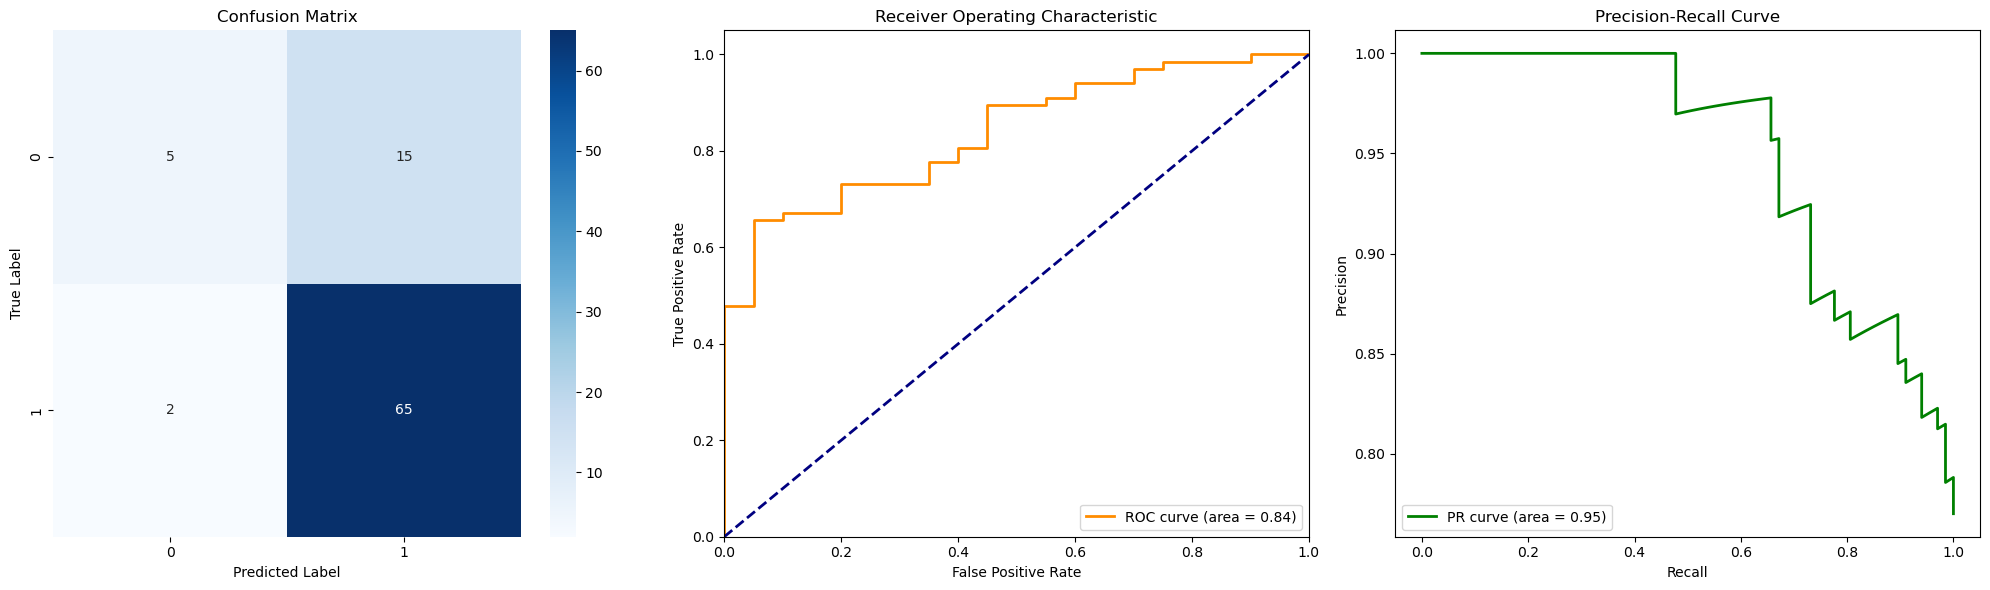

ROC-AUC: 0.8381
PR-AUC: 0.9504


In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, average_precision_score
)

# 1. Get Predictions
# We need probabilities for the curves and hard labels for the confusion matrix
y_probs_ppmi = final_model_ppmi.predict_proba(X_test_ppmi)[:, 1]

# 2. Setup Plotting Area
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test_ppmi, y_pred_ppmi)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# --- Plot 2: ROC-AUC Curve ---
fpr, tpr, _ = roc_curve(y_test_ppmi, y_probs_ppmi)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc="lower right")

# --- Plot 3: PR-AUC Curve ---
precision, recall, _ = precision_recall_curve(y_test_ppmi, y_probs_ppmi)
pr_auc = average_precision_score(y_test_ppmi, y_probs_ppmi)
ax[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
ax[2].set_xlabel('Recall')
ax[2].set_ylabel('Precision')
ax[2].set_title('Precision-Recall Curve')
ax[2].legend(loc="lower left")

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

## 10-fold CV for EPIC

Running 10-Fold CV...


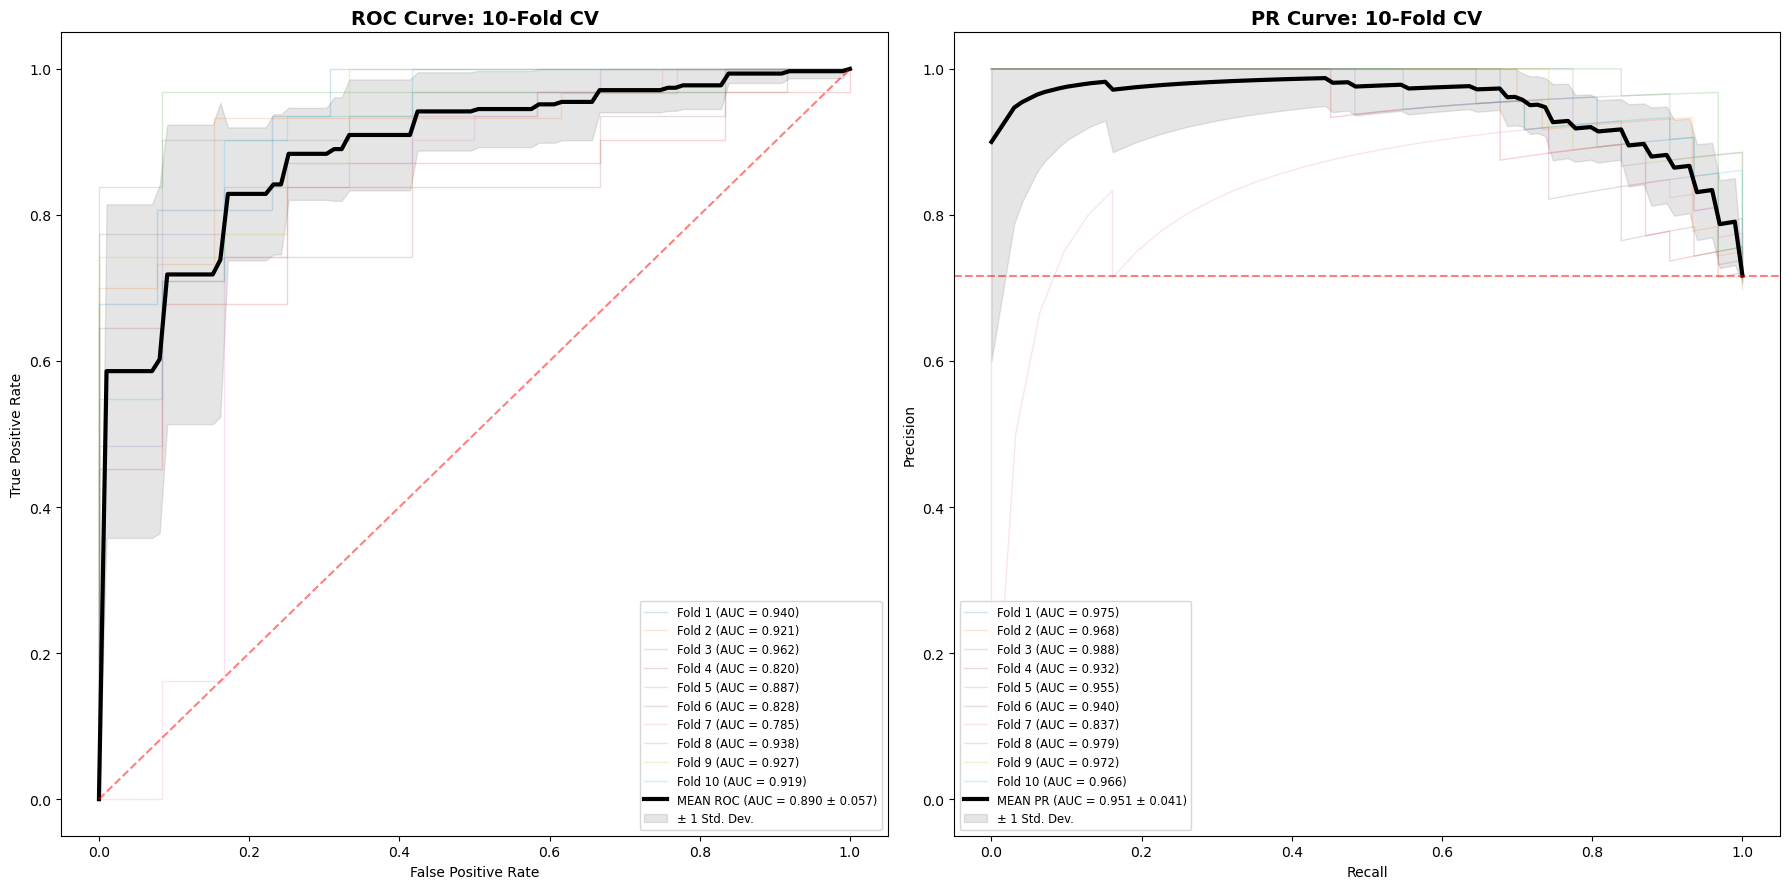

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import xgboost as xgb

# 1. Setup 10-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Buffers for averaging
tprs = []
aucs_roc = []
mean_fpr = np.linspace(0, 1, 100)

precisions = []
aucs_pr = []
mean_recall = np.linspace(0, 1, 100)

# Setup plotting area
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(18, 9))

# Configuration for GPU
xgb_params = best_params_ppmi.copy()
xgb_params.update({"tree_method": "hist", "device": "cuda"})

print("Running 10-Fold CV...")

# 2. Iterate through folds
for i, (train_idx, val_idx) in enumerate(cv.split(X_selected_ppmi, y_numpy_ppmi)):
    X_train_cv, X_val_cv = X_selected_ppmi[train_idx], X_selected_ppmi[val_idx]
    y_train_cv, y_val_cv = y_numpy_ppmi[train_idx], y_numpy_ppmi[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params, n_estimators=500)
    model.fit(X_train_cv, y_train_cv, verbose=False)
    y_probs = model.predict_proba(X_val_cv)[:, 1]
    
    # --- ROC Fold ---
    fpr, tpr, _ = roc_curve(y_val_cv, y_probs)
    fold_roc_auc = auc(fpr, tpr)
    aucs_roc.append(fold_roc_auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    
    # Plot individual fold with label for legend
    ax_roc.plot(fpr, tpr, alpha=0.2, lw=1, label=f'Fold {i+1} (AUC = {fold_roc_auc:.3f})')
    
    # --- PR Fold ---
    precision, recall, _ = precision_recall_curve(y_val_cv, y_probs)
    fold_pr_auc = average_precision_score(y_val_cv, y_probs)
    aucs_pr.append(fold_pr_auc)
    
    # Interpolate for PR
    rev_recall, rev_precision = recall[::-1], precision[::-1]
    precisions.append(np.interp(mean_recall, rev_recall, rev_precision))
    
    # Plot individual fold with label for legend
    ax_pr.plot(recall, precision, alpha=0.2, lw=1, label=f'Fold {i+1} (AUC = {fold_pr_auc:.3f})')

# 3. Calculate and Plot Mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)
mean_auc_roc = auc(mean_fpr, mean_tpr)
std_auc_roc = np.std(aucs_roc)

ax_roc.plot(mean_fpr, mean_tpr, color='black', lw=3, 
            label=f'MEAN ROC (AUC = {mean_auc_roc:.3f} ± {std_auc_roc:.3f})')

# Shade ROC Variance
ax_roc.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1), 
                     color='grey', alpha=0.2, label='± 1 Std. Dev.')

# 4. Calculate and Plot Mean PR
mean_precision = np.mean(precisions, axis=0)
std_precision = np.std(precisions, axis=0)
mean_auc_pr = np.mean(aucs_pr)
std_auc_pr = np.std(aucs_pr)

ax_pr.plot(mean_recall, mean_precision, color='black', lw=3,
           label=f'MEAN PR (AUC = {mean_auc_pr:.3f} ± {std_auc_pr:.3f})')

# Shade PR Variance
ax_pr.fill_between(mean_recall, np.maximum(mean_precision - std_precision, 0), np.minimum(mean_precision + std_precision, 1), 
                    color='grey', alpha=0.2, label='± 1 Std. Dev.')

# 5. Final Formatting
# ROC axis setup
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='red', alpha=0.5)
ax_roc.set_title('ROC Curve: 10-Fold CV', fontsize=14, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
# Use a smaller font for the legend to fit all 10 folds
ax_roc.legend(loc='lower right', fontsize='small', ncol=1)

# PR axis setup
baseline = np.sum(y_numpy_ppmi) / len(y_numpy_ppmi)
ax_pr.axhline(baseline, linestyle='--', color='red', alpha=0.5)
ax_pr.set_title('PR Curve: 10-Fold CV', fontsize=14, fontweight='bold')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left', fontsize='small', ncol=1)

plt.tight_layout()
plt.savefig('cv_detailed_results.png', dpi=300)
plt.show()

In [64]:
%conda install main::shap

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - main
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - main::shap


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    shap-0.51.0                |  py313h73fd927_1         4.2 MB  main
    slicer-0.0.8               |  py313h77c3f3f_2          44 KB
    ------------------------------------------------------------
                                           Total:         4.3 MB

The following NEW packages will be INSTALLED:

  shap               main/linux-64::shap-0.51.0-py313h73fd927_1 
  slicer             pkgs/main/linux-64::slicer-0.0.8-py313h77c3f3f_2 



shap-0.51.0          | 4.2 MB    |                                       |   0% 
slicer-0.0.8         | 44 KB     |                                

## Perform SHAP Analysis on EPIC Classification results

In [160]:
import shap
import numpy as np
import pandas as pd

# 1. Initialize the Explainer
# XGBoost models have a native integration that SHAP leverages for GPU speed
explainer_ppmi = shap.TreeExplainer(final_model_ppmi)

# 2. Calculate SHAP values
# We use the selected features dataset. 
# For XGBoost, it's often best to pass the data as a DataFrame to keep feature names
X_selected_df_ppmi = pd.DataFrame(X_selected_ppmi, columns=selected_features_epic)
shap_values_ppmi = explainer_ppmi.shap_values(X_selected_df_ppmi)

# Note: For binary classification, shap_values is often a single array.
# If your model output is a list (for multiclass), you would use shap_values[1] for the positive class.

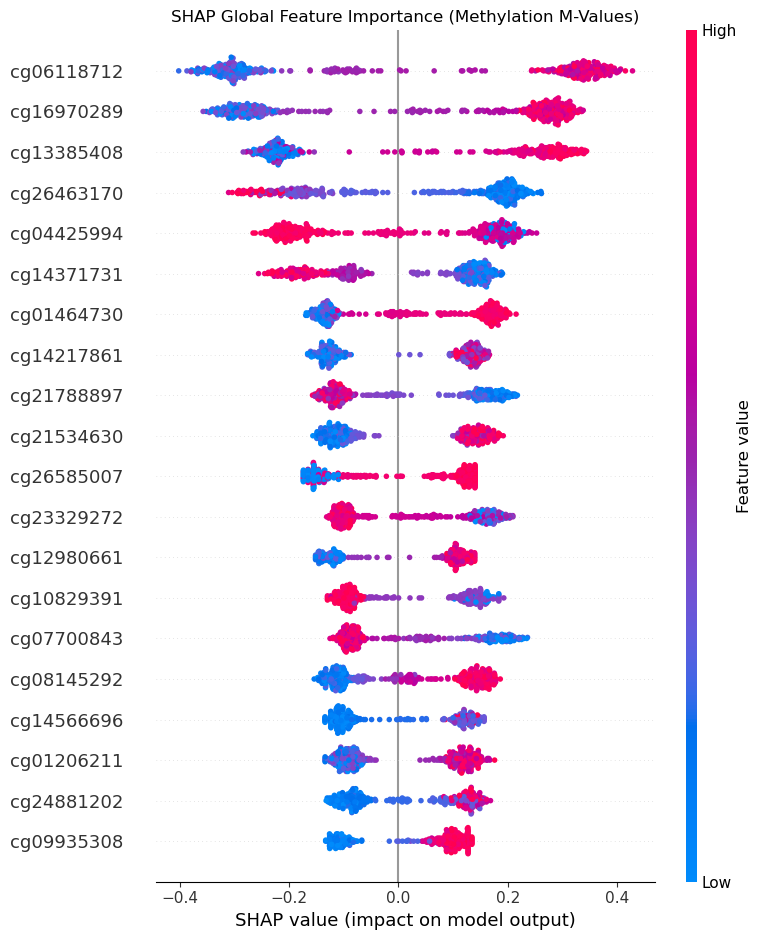

In [161]:
# 3. Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_ppmi, X_selected_df_ppmi, show=False)
plt.title("SHAP Global Feature Importance (Methylation M-Values)")
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300)
plt.show()

In [67]:
%conda install bioconda::gseapy

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
 - bioconda
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /root/miniconda3/envs/rapids-26.04

  added / updated specs:
    - bioconda::gseapy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    gseapy-1.2.1               |  py313h551aa79_0         639 KB  bioconda
    pyopengl-3.1.10            |  py313h06a4308_0         2.3 MB
    ------------------------------------------------------------
                                           Total:         3.0 MB

The following NEW packages will be INSTALLED:

  gseapy             bioconda/linux-64::gseapy-1.2.1-py313h551aa79_0 
  pyopengl           pkgs/main/linux-64::pyopengl-3.1.10-py313h06a4308_0 



pyopengl-3.1.10      | 2.3 MB    |                                       |   0% 
gseapy-1.2.1         | 639 KB    |          

## Pathway enrichment for EPIC CpG

Loading annotation manifest...
Extracting unique gene targets...
Mapped 436 CpG sites to 295 unique genes.
Running Enrichr API (requires internet connection)...

Found 28 significant pathways!


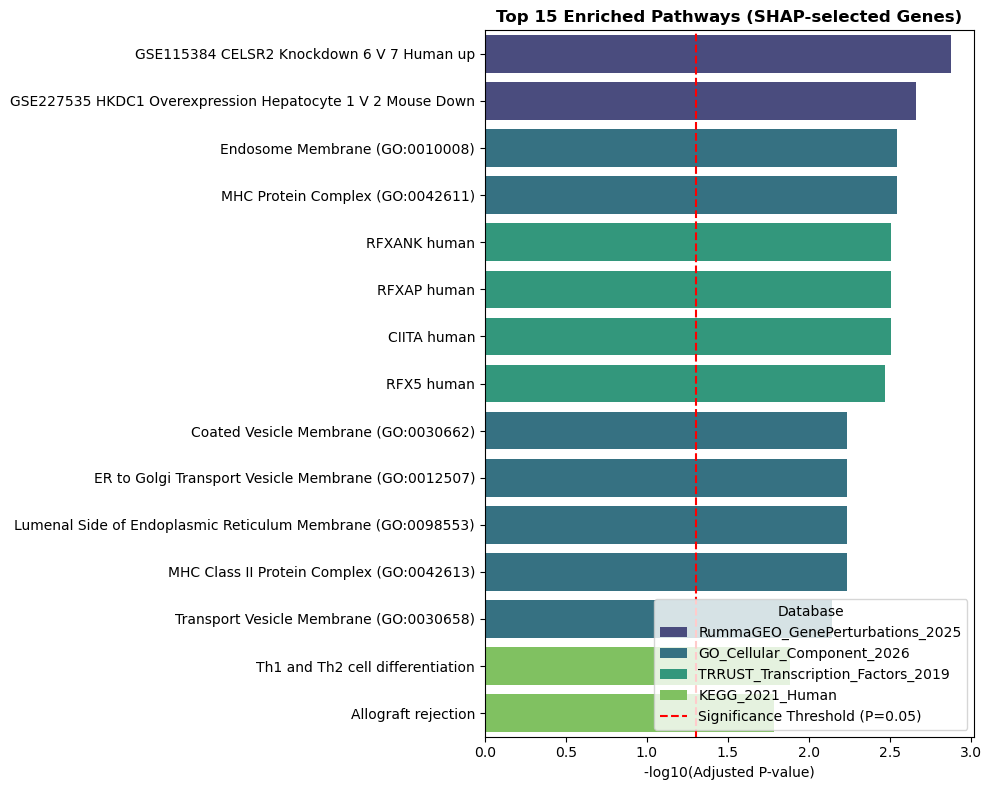

In [162]:
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Extract Top Features from SHAP ---
# Calculate the mean absolute SHAP value for every feature across all samples
shap_importances = np.abs(shap_values_ppmi).mean(axis=0)

shap_df_ppmi = pd.DataFrame({
    'CpG': X_selected_df_ppmi.columns,
    'SHAP_Importance': shap_importances
}).sort_values('SHAP_Importance', ascending=False)

top_cpgs_epic = shap_df_ppmi.head(500)

# --- 2. Load the Illumina Manifest ---
# You need the official Illumina manifest file (EPIC or 450k) downloaded locally.
# If you don't have it, you can often download the CSV version from Illumina's website.
manifest_path = '/root/data/ppmi/infinium-epic-v1.csv' 

print("Loading annotation manifest...")
# We only load the columns we care about to save memory
manifest_epic = pd.read_csv(
    manifest_path, 
    skiprows=7,
    usecols=['Name', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group'],
    dtype=str,
    encoding='utf-8'
)

# Merge our top SHAP features with the genomic annotations
mapped_cpgs_epic = pd.merge(top_cpgs_epic, manifest_epic, left_on='CpG', right_on='Name', how='left')

# --- 3. Clean Up Illumina's Gene Names ---
# Illumina manifests often list multiple genes per probe separated by semicolons
# (e.g., "GENE1;GENE1;GENE2"). We need to split these and get a unique list.
print("Extracting unique gene targets...")

# Drop probes that don't map to a known gene
genes_raw = mapped_cpgs_epic['UCSC_RefGene_Name'].dropna()

# Split semicolons, flatten the list, and remove duplicates
gene_list = genes_raw.str.split(';').explode().unique().tolist()

# Remove any empty strings just in case
gene_list = [g for g in gene_list if g.strip() != '']

print(f"Mapped {len(top_cpgs_epic)} CpG sites to {len(gene_list)} unique genes.")

# --- 4. Functional Enrichment Analysis using GSEApy ---
print("Running Enrichr API (requires internet connection)...")

# Query lots of databases to gain the most enrichment information w. statistical relevance as possible
databases = ['GO_Biological_Process_2026', 'KEGG_2021_Human', 
'ENCODE_Histone_Modifications_2015',
'ENCODE_TF_ChIP-seq_2015',
'Elsevier_Pathway_Collection',
'GO_Cellular_Component_2026',
'GO_Molecular_Function_2026',
'Ligand_Perturbations_from_GEO_down',
'Ligand_Perturbations_from_GEO_up',
'Microbe_Perturbations_from_GEO_down',
'Microbe_Perturbations_from_GEO_up',
'Panther_2016',
'ProteomicsDB_2020',
'Reactome_Pathways_2024',
'RummaGEO_GenePerturbations_2025',
'SynGO_2024',
'TRANSFAC_and_JASPAR_PWMs',
'TRRUST_Transcription_Factors_2019',
'The_Kinase_Library_2024',
'WikiPathways_2024_Human']

enrichment_results = gp.enrichr(
    gene_list=gene_list,
    gene_sets=databases,
    organism='human',
    outdir=None # Set to a path if you want to save the raw tables automatically
)

# --- 5. Visualize the Results ---
# Get the results table
res_df = enrichment_results.results

# Filter for statistically significant pathways (Adjusted P-value < 0.05)
significant_pathways_ppmi = res_df[res_df['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')

if significant_pathways_ppmi.empty:
    print("\nNo pathways reached statistical significance (Adj. P < 0.05).")
else:
    print(f"\nFound {len(significant_pathways_ppmi)} significant pathways!")
    
    # Plot the top 15 pathways
    plt.figure(figsize=(10, 8))
    
    # We use -log10(P-value) for the x-axis (longer bar = more significant)
    top_plot = significant_pathways_ppmi.head(15).copy()
    top_plot['-log10(Adj. P)'] = -np.log10(top_plot['Adjusted P-value'])
    
    sns.barplot(
        data=top_plot,
        x='-log10(Adj. P)',
        y='Term',
        hue='Gene_set',
        dodge=False,
        palette='viridis'
    )
    
    plt.title('Top 15 Enriched Pathways (SHAP-selected Genes)', fontweight='bold')
    plt.xlabel('-log10(Adjusted P-value)')
    plt.ylabel('')
    plt.axvline(-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold (P=0.05)')
    plt.legend(title='Database', loc='lower right')
    plt.tight_layout()
    plt.savefig('shap_pathway_enrichment.png', dpi=300)
    plt.show()

# Optional: Save the mapping and enrichment results to CSV for your records
mapped_cpgs_epic.to_csv('top_cpgs_annotated.csv', index=False)
significant_pathways_ppmi.to_csv('enrichment_results.csv', index=False)

Calculating SHAP directions...
Aggregating metrics to the gene level...
Calculating pathway-level SHAP metrics...
Generating visualization...


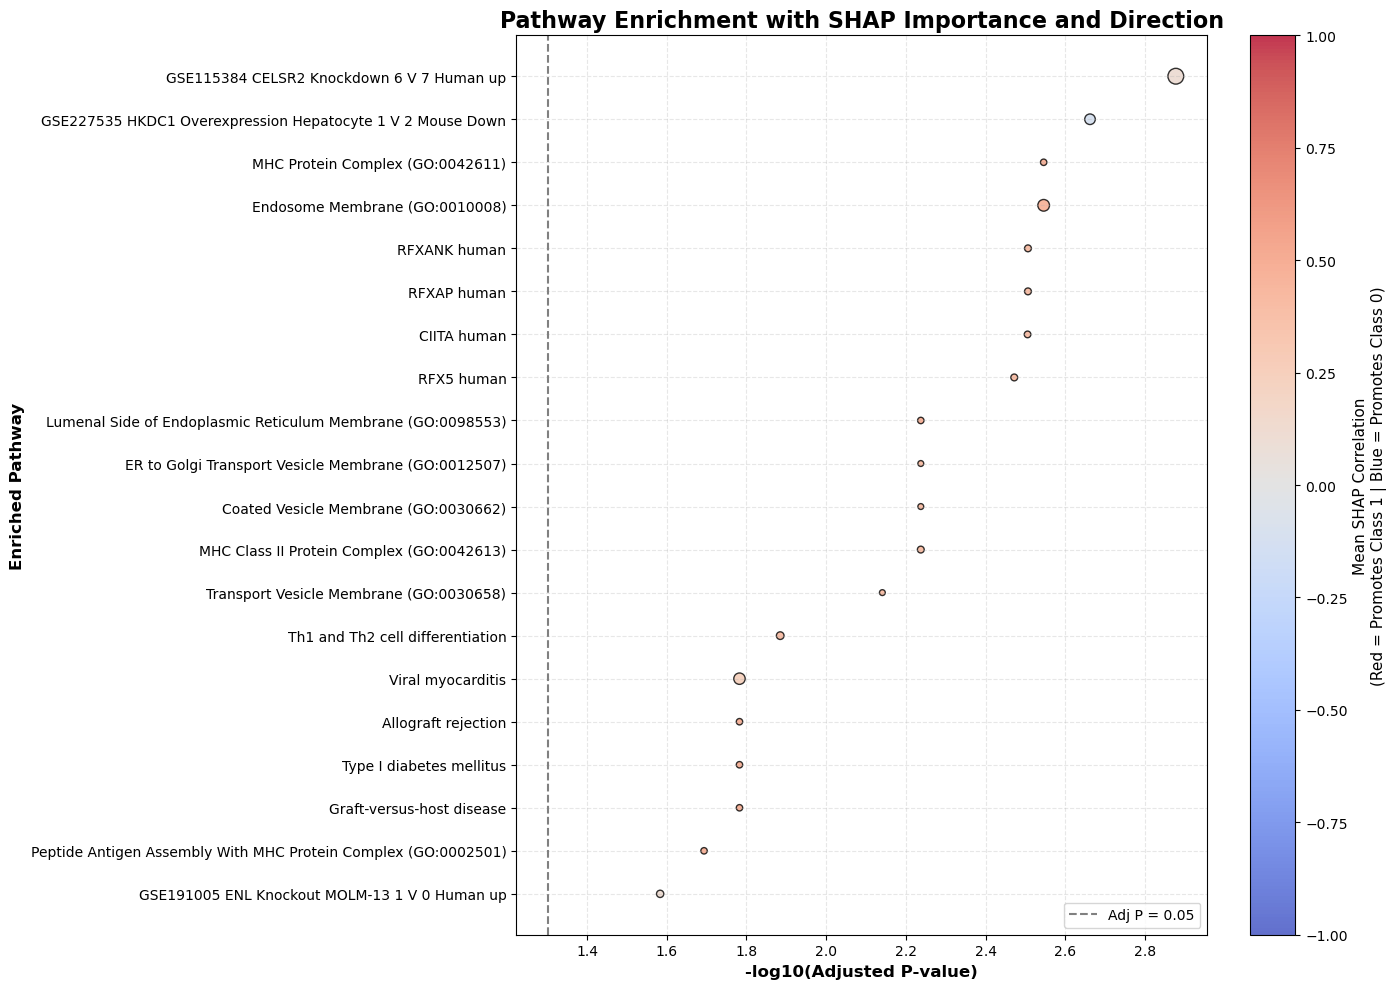

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import ast # To parse the overlap column safely

# --- 1. Calculate SHAP Direction & Importance per CpG ---
print("Calculating SHAP directions...")

cpg_stats = []
for i, cpg in enumerate(X_selected_df_ppmi.columns):
    # Importance is the mean absolute SHAP value
    importance = np.abs(shap_values_ppmi[:, i]).mean()
    
    # Direction is the correlation between the M-value and the SHAP value
    # If standard deviation is 0, correlation is 0
    feature_vals = X_selected_df_ppmi[cpg].values
    shap_vals = shap_values_ppmi[:, i]
    
    if np.std(feature_vals) == 0 or np.std(shap_vals) == 0:
        correlation = 0
    else:
        correlation, _ = pearsonr(feature_vals, shap_vals)
        
    cpg_stats.append({
        'CpG': cpg,
        'SHAP_Importance': importance,
        'SHAP_Correlation': correlation
    })

cpg_df = pd.DataFrame(cpg_stats)

# --- 2. Map CpGs to Genes and Aggregate ---
print("Aggregating metrics to the gene level...")

# Merge with the manifest (assuming you still have 'mapped_cpgs_epic' from the previous step)
mapped_stats = pd.merge(cpg_df, mapped_cpgs_epic[['CpG', 'UCSC_RefGene_Name']], on='CpG', how='inner')

# Clean up genes (split semicolons)
mapped_stats = mapped_stats.dropna(subset=['UCSC_RefGene_Name'])
mapped_stats['UCSC_RefGene_Name'] = mapped_stats['UCSC_RefGene_Name'].str.split(';')
mapped_stats = mapped_stats.explode('UCSC_RefGene_Name')
mapped_stats['Gene'] = mapped_stats['UCSC_RefGene_Name'].str.strip()

# Aggregate SHAP Importance (Sum) and Direction (Mean) per Gene
gene_stats = mapped_stats.groupby('Gene').agg({
    'SHAP_Importance': 'sum',
    'SHAP_Correlation': 'mean' 
}).reset_index()

# Create a dictionary for rapid lookup
gene_importance_dict = dict(zip(gene_stats['Gene'], gene_stats['SHAP_Importance']))
gene_direction_dict = dict(zip(gene_stats['Gene'], gene_stats['SHAP_Correlation']))


# --- 3. Process Enrichr Results ---
print("Calculating pathway-level SHAP metrics...")

# Assuming `res_df` is your output dataframe from gp.enrichr().results
# Filter for significant pathways
sig_pathways = res_df[res_df['Adjusted P-value'] < 0.05].copy()

if sig_pathways.empty:
    raise ValueError("No significant pathways found to plot. Try relaxing the P-value or use Preranked GSEA.")

# Add custom metrics to the pathways
pathway_data = []

for index, row in sig_pathways.iterrows():
    # Enrichr returns overlapping genes as a string separated by semicolons
    overlap_genes = row['Genes'].split(';') 
    
    # Calculate Pathway SHAP Importance (Mean importance of the overlapping genes)
    p_importances = [gene_importance_dict.get(g, 0) for g in overlap_genes]
    pathway_importance = np.mean(p_importances) if p_importances else 0
    
    # Calculate Pathway Direction (Mean correlation of the overlapping genes)
    p_directions = [gene_direction_dict.get(g, 0) for g in overlap_genes]
    pathway_direction = np.mean(p_directions) if p_directions else 0
    
    pathway_data.append({
        'Term': row['Term'],
        'Database': row['Gene_set'],
        '-log10(Adj.P)': -np.log10(row['Adjusted P-value']),
        'Pathway_Importance': pathway_importance,
        'Pathway_Direction': pathway_direction,
        'Gene_Count': len(overlap_genes)
    })

plot_df = pd.DataFrame(pathway_data)

# Sort by significance and take the top 20 to avoid overcrowding the plot
plot_df = plot_df.sort_values('-log10(Adj.P)', ascending=False).head(20)


# --- 4. Generate the Advanced Bubble Plot ---
print("Generating visualization...")
plt.figure(figsize=(14, 10))

# Create the scatter plot
scatter = plt.scatter(
    x=plot_df['-log10(Adj.P)'], 
    y=plot_df['Term'],
    s=plot_df['Pathway_Importance'] * 1000, # Scale up for visibility
    c=plot_df['Pathway_Direction'], 
    cmap='coolwarm',       # Blue (negative) to Red (positive)
    edgecolors='black', 
    alpha=0.8,
    vmin=-1, vmax=1      # Fix scale bounds for correlation
)

# Formatting
plt.title('Pathway Enrichment with SHAP Importance and Direction', fontsize=16, fontweight='bold')
plt.xlabel('-log10(Adjusted P-value)', fontsize=12, fontweight='bold')
plt.ylabel('Enriched Pathway', fontsize=12, fontweight='bold')

# Colorbar for Direction
cbar = plt.colorbar(scatter)
cbar.set_label('Mean SHAP Correlation\n(Red = Promotes Class 1 | Blue = Promotes Class 0)', fontsize=11)

# Add a significance threshold line
plt.axvline(-np.log10(0.05), color='gray', linestyle='--', label='Adj P = 0.05')
plt.legend(loc='lower right')

# Clean up the Y-axis labels
plt.gca().invert_yaxis() # Put most significant at the top
plt.grid(True, axis='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_pathway_bubble_plot.png', dpi=300)
plt.show()

# 2. Validate process
___
*The validation* is performed by:
1. Find the common features from the set of selected ones on the GSE111629 dataset.
2. Train an XGB Classifier on the common features with values from PPMI.
3. Run predictions on GSE111629.

In [164]:
import pandas as pd

# 1. Load your selected features (assuming it's a list or numpy array from earlier)
# selected_features = ... (Your 431 CpG names)
selected_set = set(selected_features_epic)

# 2. Load the 450k Manifest
print("Loading 450k Manifest...")
# We use skiprows=7 because Illumina CSVs usually have 7 lines of header info before the data table
manifest_450k_path = '/root/data/ppmi/450k.csv'
manifest_450k = pd.read_csv(manifest_450k_path, skiprows=7, usecols=['IlmnID'], dtype=str)

# 3. Create a set of all 450k probes
probes_450k = set(manifest_450k['IlmnID'].dropna())

# 4. Perform Set Operations
# Intersection: Probes in BOTH your selected features AND the 450k array
shared_cpgs = selected_set.intersection(probes_450k)

# Difference: Probes in your selected features but NOT in the 450k array (Unique to EPIC)
epic_only_cpgs = selected_set.difference(probes_450k)

print(f"Total features selected by model: {len(selected_set)}")
print(f"Features present in both EPIC and 450k arrays: {len(shared_cpgs)}")
print(f"Features unique to the EPIC array: {len(epic_only_cpgs)}")

# 5. Optional: Add this information back to your original SHAP dataframe for your records
if 'cpg_df' in locals():
    cpg_df['In_450k_Array'] = cpg_df['CpG'].apply(lambda x: x in shared_cpgs)
    print("\nUpdated SHAP Dataframe:")
    print(cpg_df[['CpG', 'SHAP_Importance', 'In_450k_Array']].head())

Loading 450k Manifest...
Total features selected by model: 436
Features present in both EPIC and 450k arrays: 184
Features unique to the EPIC array: 252

Updated SHAP Dataframe:
          CpG  SHAP_Importance  In_450k_Array
0  cg17156349         0.000000           True
1  cg07700843         0.110504           True
2  cg13402298         0.009018           True
3  cg14767338         0.048748          False
4  cg16652920         0.016664           True


In [167]:

print(f"Original EPIC dataset shape: {df_ppmi.shape}")

# 1. Find the exact overlap between your dataset's columns and the 450k manifest
# This drops any EPIC-exclusive probes
overlapping_cpgs = list(set(df_ppmi.columns).intersection(probes_450k))

# 2. Don't forget to keep your target/label column! 
label_col = 'Sample_Group'

columns_to_keep = overlapping_cpgs.copy()
if label_col in df_ppmi.columns:
    columns_to_keep.append(label_col)
    
# 3. Create the reduced DataFrame
df_450k_compatible = df_ppmi[columns_to_keep]

print(f"Reduced 450k-compatible dataset shape: {df_450k_compatible.shape}")

# 4. Optional but recommended: Save this reduced dataset so you don't have to 
# load the massive EPIC file next time
df_450k_compatible.to_parquet('/root/data/ppmi/data_ppmi_450k_filtered.parquet')

Original EPIC dataset shape: (431, 776968)
Reduced 450k-compatible dataset shape: (431, 400987)


In [169]:
target_var = "Sample_Group"
meta_cols_reduced = [col for col in df_450k_compatible.columns if not col.startswith("cg")]

In [172]:
Y_pd_reduced = df_450k_compatible[target_var]
X_pd_reduced = df_450k_compatible.drop(columns=meta_cols_reduced)

Y_pd_reduced = Y_pd_reduced.map({"Control": 0, "PD": 1})

In [176]:
X_reduced = X_pd_reduced.to_numpy(dtype="float32")
Y_reduced = Y_pd_reduced.to_numpy(dtype="float32")

In [177]:
from cuml.linear_model import LogisticRegression

enet_classifier_reduced = LogisticRegression(
    penalty='elasticnet',
    C=1.0,
    l1_ratio=0.5,
    solver='qn',
    max_iter=10000
)
enet_classifier_reduced.fit(X_reduced, Y_reduced)

[2026-05-09 18:28:14.231] [CUML] [warning] QWL-QN: max iterations reached
[2026-05-09 18:28:14.232] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


LogisticRegression()

In [178]:
coefficients_reduced = enet_classifier_reduced.coef_.flatten()

In [179]:
feature_names_reduced = X_pd_reduced.columns.to_numpy()

In [180]:
import numpy as np
selected_mask_reduced = np.abs(coefficients_reduced) > 1e-6

In [181]:
selected_features_reduced = feature_names_reduced[selected_mask_reduced]
selected_weights_reduced = coefficients_reduced[selected_mask_reduced]

print(f"Total features originally: {len(feature_names_reduced)}")
print(f"Features selected by ElasticNet: {len(selected_features_reduced)}")

Total features originally: 398471
Features selected by ElasticNet: 484


### Load the GSE111629 M-values

In [183]:
df_gse = pd.read_parquet("/root/data/gse/data_gse111629.parquet")

In [184]:
df_gse = df_gse[df_gse["Sample_Group"].isin(["Control", "PD"])]
target_var = "Sample_Group"
meta_cols_gse = [col for col in df_gse.columns if not col.startswith("cg")]

In [185]:
Y_pd_gse = df_gse[target_var]
X_pd_gse = df_gse.drop(columns=meta_cols_gse)
X_selected_gse = X_pd_gse[X_pd_gse.columns.intersection(selected_features_reduced)]

Y_pd_gse = Y_pd_gse.map({"Control": 0, "PD": 1})

In [188]:
X_pd_reduced_ppmi_gse = X_pd_reduced[X_pd_reduced.columns.intersection(X_selected_gse.columns)] 

In [190]:
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Filter your data to the selected features only
# X_pd and Y_pd are your cleaned Pandas objects from the previous step
X_numpy_reduced = X_pd_reduced_ppmi_gse.to_numpy(dtype=np.float32)
y_numpy_reduced = Y_pd_reduced.to_numpy(dtype=np.float32)

# 2. Split into training and validation sets
X_train_reduced, X_valid_reduced, y_train_reduced, y_valid_reduced = train_test_split(
    X_numpy_reduced, y_numpy_reduced, test_size=0.2, random_state=42
)

# 3. Define the Objective Function for Optuna
def objective(trial):
    # Define the search space
    param = {
        "verbosity": 0,
        "objective": "binary:logistic",
        # GPU Settings
        "tree_method": "hist",
        "device": "cuda",
        # Hyperparameters to tune
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, step=0.01),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

    # Add a pruning callback to stop unpromising trials early
    model = xgb.XGBClassifier(**param, n_estimators=1000, early_stopping_rounds=50)
    
    model.fit(
        X_train_reduced, y_train_reduced,
        eval_set=[(X_valid_reduced, y_valid_reduced)],
        verbose=False
    )

    preds = model.predict_proba(X_valid_reduced)[:, 1]
    auc = roc_auc_score(y_valid_reduced, preds)
    return auc

# 4. Run the Study
print("Starting Hyperparameter Tuning on GPU...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50) # Increase n_trials for better results

print("\n--- Optimization Finished ---")
print(f"Best AUC: {study.best_value:.4f}")
print("Best Params:", study.best_params)

# 5. Train Final Model with Best Parameters
best_params = study.best_params
best_params["tree_method"] = "hist"
best_params["device"] = "cuda"

final_model = xgb.XGBClassifier(**best_params, n_estimators=500)
final_model.fit(X_train_reduced, y_train_reduced)

[I 2026-05-09 18:37:11,895] A new study created in memory with name: no-name-78958072-12f0-4f6a-a3b5-cd2a538f0598


Starting Hyperparameter Tuning on GPU...


[I 2026-05-09 18:37:12,868] Trial 0 finished with value: 0.7917910447761194 and parameters: {'lambda': 2.587975386093317, 'alpha': 0.00722715618826842, 'learning_rate': 0.03, 'max_depth': 8, 'subsample': 0.6410746063096252, 'colsample_bytree': 0.801888598380103, 'min_child_weight': 10}. Best is trial 0 with value: 0.7917910447761194.
[I 2026-05-09 18:37:13,339] Trial 1 finished with value: 0.814179104477612 and parameters: {'lambda': 0.006254067806238808, 'alpha': 0.11776157968373235, 'learning_rate': 0.060000000000000005, 'max_depth': 8, 'subsample': 0.8079686956263841, 'colsample_bytree': 0.8104520190744804, 'min_child_weight': 7}. Best is trial 1 with value: 0.814179104477612.
[I 2026-05-09 18:37:14,644] Trial 2 finished with value: 0.8477611940298507 and parameters: {'lambda': 1.8170943036767542, 'alpha': 0.18504298708718717, 'learning_rate': 0.03, 'max_depth': 5, 'subsample': 0.8022559518877834, 'colsample_bytree': 0.7832674377438791, 'min_child_weight': 1}. Best is trial 2 with v


--- Optimization Finished ---
Best AUC: 0.9381
Best Params: {'lambda': 0.005623162484928751, 'alpha': 0.00570851943889332, 'learning_rate': 0.03, 'max_depth': 9, 'subsample': 0.5654615927025542, 'colsample_bytree': 0.9817900545658829, 'min_child_weight': 2}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9817900545658829
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impor

In [193]:
X = X_selected_gse.to_numpy(dtype="float32")
Y = Y_pd_gse.to_numpy(dtype="float32")

In [194]:
Y_probs = final_model.predict_proba(X)[:, 1]
Y_pred = final_model.predict(X)

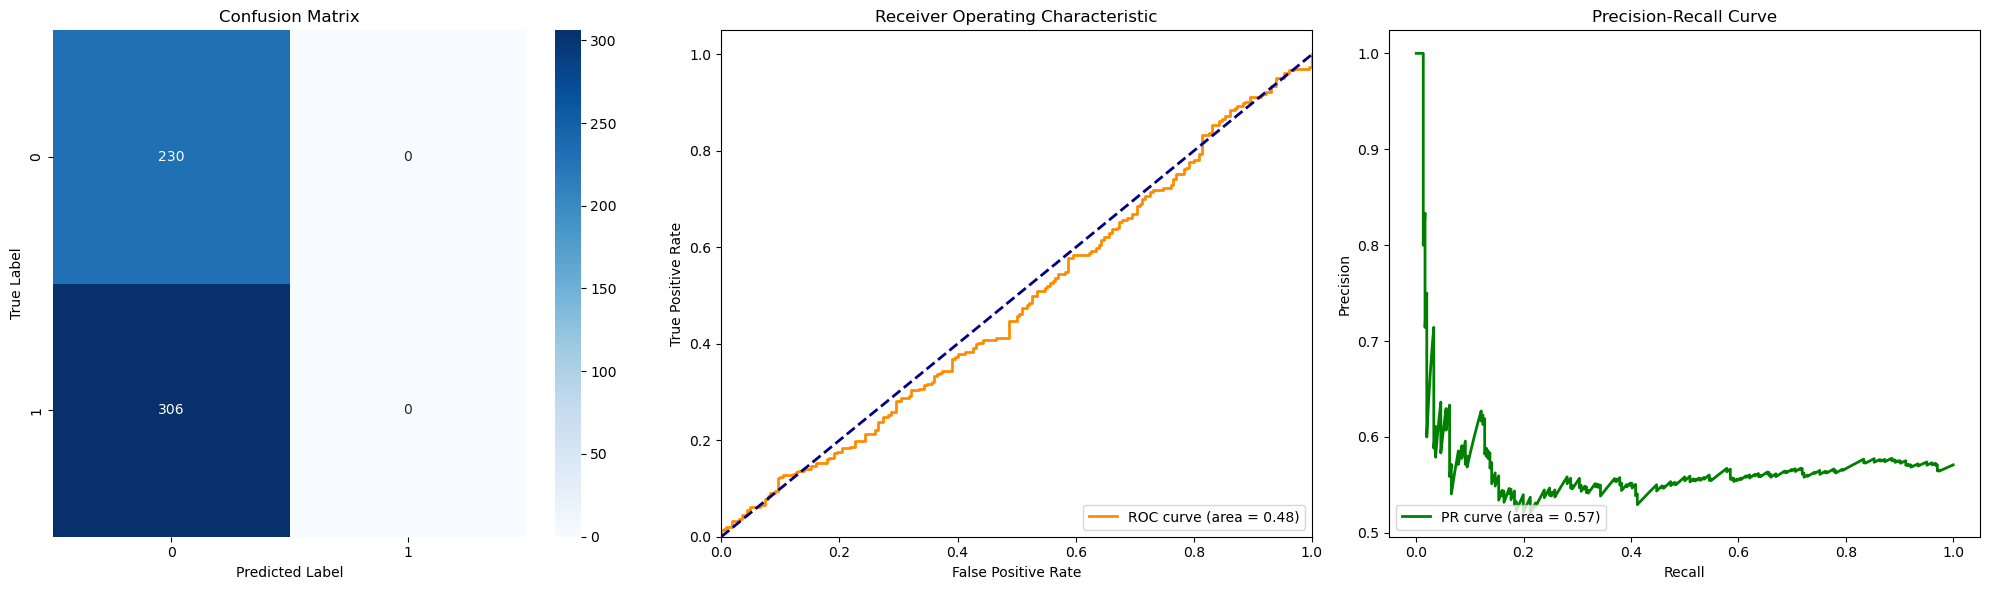

ROC-AUC: 0.4816
PR-AUC: 0.5709


In [195]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
cm = confusion_matrix(Y, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

fpr, tpr, _ = roc_curve(Y, Y_probs)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc="lower right")

precision, recall, _ = precision_recall_curve(Y, Y_probs)
pr_auc = average_precision_score(Y, Y_probs)
ax[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
ax[2].set_xlabel('Recall')
ax[2].set_ylabel('Precision')
ax[2].set_title('Precision-Recall Curve')
ax[2].legend(loc="lower left")

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")